In [18]:
# "Carga y consumo de datasets con Pandas
#Dataset 1:** `estudiantes.csv` — origen CSV  
#Dataset 2:** `academico.db` — origen base de datos SQLite  

#En este notebook:
#1. Cargamos cada fuente por separado
#2. Exploramos su estructura
#3. Los unimos en un DataFrame final
#4. Limpiamos y enriquecemos los datos
#5. Guardamos el dataset final

In [19]:
## Paso 1 — Instalar e importar librerías
!pip install pandas

In [20]:
import pandas as pd
import sqlite3
import os
import pygwalker as pyg
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import ColumnDataSource

output_notebook()

pd.set_option('display.max_columns', None)   # Mostrar todas las columnas
pd.set_option('display.float_format', '{:.2f}'.format)  # Decimales limpios

print(f'Pandas versión : {pd.__version__}')
print(f'Directorio actual: {os.getcwd()}')

Loading BokehJS ...

Pandas versión : 2.3.3
Directorio actual: D:\Maestría IA 2026\01.- Herramientas de IA\Tareas\ProyectoFinal\ProyectoFinal


In [21]:
## Paso 2 — Dataset 1: cargar el CSV con Pandas

In [22]:
df_csv = pd.read_csv('data/estudiantes.csv', encoding='utf-8')

print('=== Dimensiones ===')
print(f'Filas: {df_csv.shape[0]}  |  Columnas: {df_csv.shape[1]}')

print('\n=== Primeras 5 filas ===')
display(df_csv.head())

=== Dimensiones ===
Filas: 2000  |  Columnas: 19

=== Primeras 5 filas ===


,id_estudiante,nombre,apellido,genero,edad,ciudad,jornada,nivel,matematica,lenguaje,ciencias,historia,ingles,educacion_fisica,promedio_general,asistencia_pct,clases_asistidas,clases_faltadas,aprobado
0,1,Cristian,López Romero,M,18,Quito,Matutina,Primero,16.00,17.50,16.70,16.40,14.70,15.50,16.13,89.70,161,19,Sí
1,2,Juan,Medina Reyes,M,17,Manta,Matutina,Primero,18.30,17.30,17.90,18.10,18.00,16.90,17.75,94.00,169,11,Sí
2,3,Alejandro,López Castillo,M,17,Esmeraldas,Vespertina,Tercero,10.40,10.90,9.30,9.00,12.40,11.00,10.50,83.70,151,29,No
3,4,Carolina,Hernández Morales,F,17,Ambato,Vespertina,Tercero,13.80,11.80,11.80,12.20,11.90,12.50,12.33,69.30,125,55,No
4,5,Mateo,Soto Vega,M,15,Ambato,Matutina,Segundo,18.80,19.70,20.00,18.90,18.80,19.40,19.27,80.40,145,35,Sí


In [23]:
print('=== Tipos de datos ===')
print(df_csv.dtypes)

print('\n=== Valores nulos por columna ===')
nulos = df_csv.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Sin valores nulos')

=== Tipos de datos ===
id_estudiante         int64
nombre               object
apellido             object
genero               object
edad                  int64
ciudad               object
jornada              object
nivel                object
matematica          float64
lenguaje            float64
ciencias            float64
historia            float64
ingles              float64
educacion_fisica    float64
promedio_general    float64
asistencia_pct      float64
clases_asistidas      int64
clases_faltadas       int64
aprobado             object
dtype: object

=== Valores nulos por columna ===
Sin valores nulos


In [24]:
print('=== Estadísticas descriptivas — notas ===')
cols_notas = ['matematica','lenguaje','ciencias','historia','ingles','educacion_fisica','promedio_general']
display(df_csv[cols_notas].describe().round(2))

print('\n=== Variables categóricas ===')
for col in ['genero','nivel','jornada','aprobado']:
    print(f'  {col}: {df_csv[col].value_counts().to_dict()}')

=== Estadísticas descriptivas — notas ===


,matematica,lenguaje,ciencias,historia,ingles,educacion_fisica,promedio_general
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,14.00,14.19,14.14,14.46,13.79,14.94,14.25
std,2.66,2.71,2.72,2.69,2.67,2.67,2.47
min,6.00,5.40,4.90,6.30,5.80,6.10,6.93
25%,12.20,12.40,12.28,12.60,12.00,13.18,12.62
50%,14.00,14.20,14.20,14.40,13.80,15.00,14.32
75%,15.80,16.10,16.00,16.20,15.60,16.80,15.90
max,20.00,20.00,20.00,20.00,20.00,20.00,19.95



=== Variables categóricas ===
  genero: {'F': 1011, 'M': 989}
  nivel: {'Primero': 701, 'Segundo': 660, 'Tercero': 639}
  jornada: {'Vespertina': 1024, 'Matutina': 976}
  aprobado: {'Sí': 1089, 'No': 911}


In [25]:
## Paso 3 — Dataset 2: cargar desde SQLite con Pandas

In [26]:
# ************************************************
# ****************Conectar a la base de datos*****
#*************************************************
conn = sqlite3.connect(r'D:\Maestría IA 2026\01.- Herramientas de IA\Tareas\ProyectoFinal\ProyectoFinal\data\academico.db')
print('Conexión a academico.db exitosa')

# Listar todas las tablas disponibles
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(f'\nTablas encontradas: {tablas["name"].tolist()}')

Conexión a academico.db exitosa

Tablas encontradas: ['materias', 'docentes', 'curso_materia', 'estudiantes', 'inscripciones', 'sqlite_sequence']


In [27]:
# ── Tabla: materias ──────────────────────────────────────────
df_materias = pd.read_sql('SELECT * FROM materias', conn)
print('=== Tabla: materias ===')
display(df_materias)

# ── Tabla: docentes ──────────────────────────────────────────
df_docentes = pd.read_sql('SELECT * FROM docentes', conn)
print('\n=== Tabla: docentes ===')
display(df_docentes)

=== Tabla: materias ===


,id,nombre,codigo,horas_sem,area
0,1,Matemática,MAT-01,4,Exactas
1,2,Lengua y Literatura,LEN-01,4,Humanidades
2,3,Ciencias Naturales,CIE-01,3,Ciencias
3,4,Historia y CCSS,HIS-01,3,Humanidades
4,5,Inglés,ING-01,3,Idiomas
5,6,Educación Física,EFI-01,2,Deportes



=== Tabla: docentes ===


,id,nombre,especialidad,anios_exp,formacion
0,1,Prof. Rosa Andrade,Matemática,12,Licenciatura
1,2,Prof. Marco Salinas,Lengua y Literatura,8,Magíster
2,3,Prof. Elena Figueroa,Biología,15,Magíster
3,4,Prof. Tomás Guerrero,Historia,6,Licenciatura
4,5,Prof. Sandra Brito,Inglés,10,Certificación CELTA
5,6,Prof. Ramiro Cevallos,Deportes,9,Licenciatura


In [28]:
import sqlite3

conn = sqlite3.connect("data/academico.db")
cur = conn.cursor()

for tabla in ['materias', 'docentes', 'curso_materia', 'inscripciones']:
    cur.execute(f'PRAGMA table_info({tabla})')
    cols = cur.fetchall()
    print(f'--- {tabla} ---')
    for c in cols:
        print(f'  {c[1]} ({c[2]})')

conn.close()

--- materias ---
  id (INTEGER)
  nombre (TEXT)
  codigo (TEXT)
  horas_sem (INTEGER)
  area (TEXT)
--- docentes ---
  id (INTEGER)
  nombre (TEXT)
  especialidad (TEXT)
  anios_exp (INTEGER)
  formacion (TEXT)
--- curso_materia ---
  id (INTEGER)
  id_materia (INTEGER)
  id_docente (INTEGER)
  nivel (TEXT)
  jornada (TEXT)
  cupo_max (INTEGER)
  aula (TEXT)
--- inscripciones ---
  id (INTEGER)
  id_estudiante (INTEGER)
  id_curso_materia (INTEGER)
  nota_obtenida (REAL)
  estado (TEXT)


In [43]:
with sqlite3.connect("data/academico.db") as conn:
    print(pd.read_sql("PRAGMA table_info(docentes);", conn))

   cid          name     type  notnull dflt_value  pk
0    0            id  INTEGER        0       None   1
1    1        nombre     TEXT        1       None   0
2    2  especialidad     TEXT        1       None   0
3    3     anios_exp  INTEGER        1       None   0
4    4     formacion     TEXT        1       None   0


In [44]:
print(pd.read_sql("PRAGMA table_info(docentes);", conn))

   cid          name     type  notnull dflt_value  pk
0    0            id  INTEGER        0       None   1
1    1        nombre     TEXT        1       None   0
2    2  especialidad     TEXT        1       None   0
3    3     anios_exp  INTEGER        1       None   0
4    4     formacion     TEXT        1       None   0


In [45]:
conn = sqlite3.connect("data/academico.db")

query = """
    SELECT
        i.id_estudiante,
        m.nombre        AS materia,
        m.area,
        d.nombre        AS docente,
        d.anios_exp,
        cm.nivel,
        cm.jornada,
        cm.aula,
        i.nota_obtenida,
        i.estado
    FROM inscripciones i
    JOIN curso_materia cm ON i.id_curso_materia = cm.id
    JOIN materias m       ON cm.id_materia = m.id
    JOIN docentes d       ON cm.id_docente = d.id
    ORDER BY i.id_estudiante, m.nombre
"""

df_bd = pd.read_sql(query, conn)
conn.close()

print(f'Dimensiones: {df_bd.shape}')
display(df_bd.head(12))

Dimensiones: (12000, 10)


,id_estudiante,materia,area,docente,anios_exp,nivel,jornada,aula,nota_obtenida,estado
0,1,Ciencias Naturales,Ciencias,Prof. Elena Figueroa,15,Primero,Matutina,C-301,16.70,Aprobado
1,1,Educación Física,Deportes,Prof. Ramiro Cevallos,9,Primero,Matutina,B-202,15.50,Aprobado
2,1,Historia y CCSS,Humanidades,Prof. Tomás Guerrero,6,Primero,Matutina,B-202,16.40,Aprobado
3,1,Inglés,Idiomas,Prof. Sandra Brito,10,Primero,Matutina,A-102,14.70,Aprobado
4,1,Lengua y Literatura,Humanidades,Prof. Marco Salinas,8,Primero,Matutina,A-102,17.50,Aprobado
5,1,Matemática,Exactas,Prof. Rosa Andrade,12,Primero,Matutina,B-202,16.00,Aprobado
6,2,Ciencias Naturales,Ciencias,Prof. Elena Figueroa,15,Primero,Matutina,C-301,17.90,Aprobado
7,2,Educación Física,Deportes,Prof. Ramiro Cevallos,9,Primero,Matutina,B-202,16.90,Aprobado
8,2,Historia y CCSS,Humanidades,Prof. Tomás Guerrero,6,Primero,Matutina,B-202,18.10,Aprobado
9,2,Inglés,Idiomas,Prof. Sandra Brito,10,Primero,Matutina,A-102,18.00,Aprobado


In [46]:
print('=== Resumen dataset BD ===')
print(f'Estudiantes únicos : {df_bd["id_estudiante"].nunique()}')
print(f'Materias distintas : {df_bd["materia"].nunique()}')
print(f'Docentes distintos : {df_bd["docente"].nunique()}')

print('\n=== Inscripciones por materia ===')
display(df_bd.groupby('materia')['nota_obtenida'].agg(['count','mean','min','max']).round(2))

print('\n=== Aprobados vs Reprobados por materia ===')
display(df_bd.groupby(['materia','estado']).size().unstack(fill_value=0))

=== Resumen dataset BD ===
Estudiantes únicos : 2000
Materias distintas : 6
Docentes distintos : 6

=== Inscripciones por materia ===


,count,mean,min,max
materia,,,,
Ciencias Naturales,2000,14.14,4.90,20.00
Educación Física,2000,14.94,6.10,20.00
Historia y CCSS,2000,14.46,6.30,20.00
Inglés,2000,13.79,5.80,20.00
Lengua y Literatura,2000,14.19,5.40,20.00
Matemática,2000,14.00,6.00,20.00



=== Aprobados vs Reprobados por materia ===


estado,Aprobado,Reprobado
materia,,
Ciencias Naturales,1055,945
Educación Física,1280,720
Historia y CCSS,1142,858
Inglés,958,1042
Lengua y Literatura,1070,930
Matemática,1021,979


In [47]:
#😁Visualizaciones con Matplotlib

In [48]:
import matplotlib.pyplot as plt

In [49]:
#Distribución de estados académicos

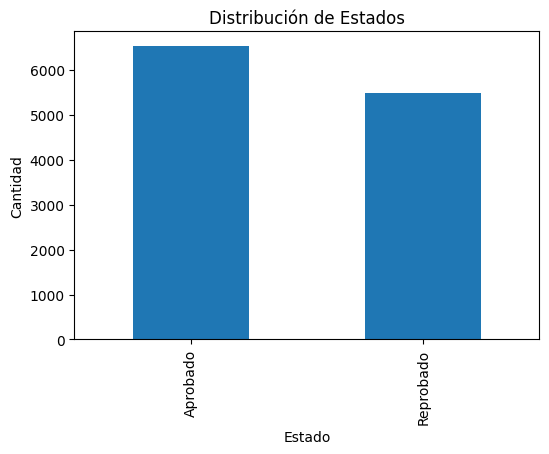

In [50]:
estado_counts = df_bd["estado"].value_counts()

plt.figure(figsize=(6,4))
estado_counts.plot(kind="bar")

plt.title("Distribución de Estados")
plt.xlabel("Estado")
plt.ylabel("Cantidad")

plt.show()

In [51]:
#Promedio de notas por materia

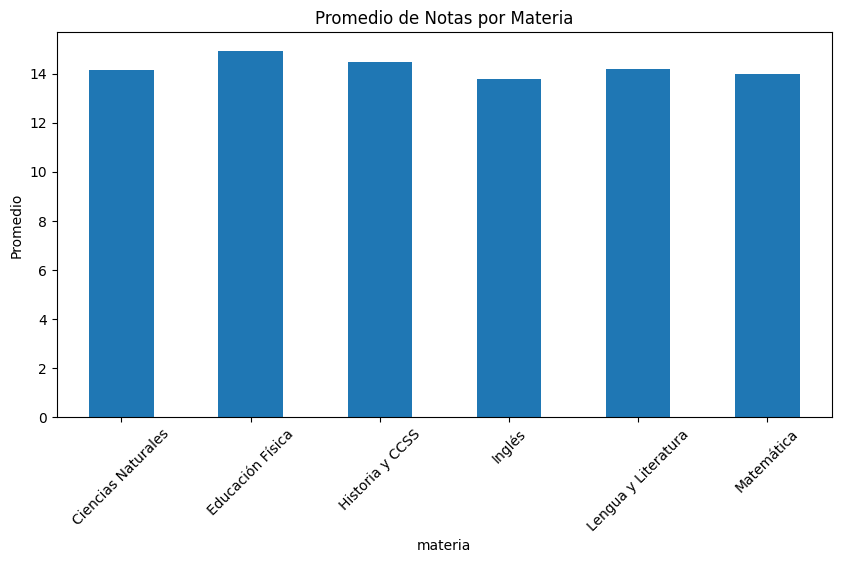

In [52]:
promedios = df_bd.groupby("materia")["nota_obtenida"].mean()

plt.figure(figsize=(10,5))
promedios.plot(kind="bar")

plt.title("Promedio de Notas por Materia")
plt.ylabel("Promedio")
plt.xticks(rotation=45)

plt.show()

In [53]:
#Histograma de notas

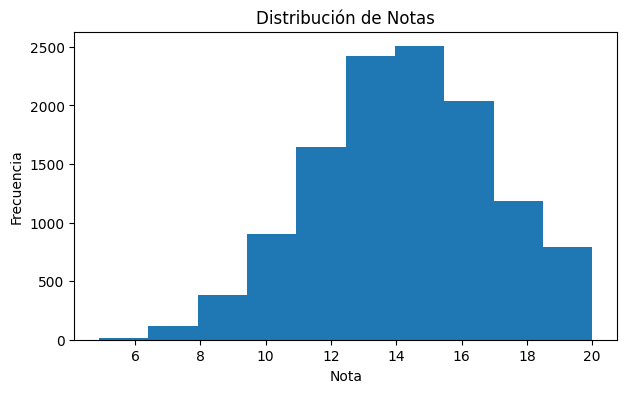

In [54]:
plt.figure(figsize=(7,4))

plt.hist(df_bd["nota_obtenida"], bins=10)

plt.title("Distribución de Notas")
plt.xlabel("Nota")
plt.ylabel("Frecuencia")

plt.show()

In [55]:
#😁Visualizaciones Interactivas con Bokeh

In [61]:
estado_counts = df_bd["estado"].value_counts()

source = ColumnDataSource(data=dict(
    estados=estado_counts.index.tolist(),
    cantidades=estado_counts.values.tolist()
))

p = figure(
    x_range=estado_counts.index.tolist(),
    height=400,
    title="Estados Académicos"
)

p.vbar(
    x='estados',
    top='cantidades',
    width=0.5,
    source=source
)

show(p)

In [57]:
#😁➡️Exploración Visual con PyWalker

In [58]:
#!pip install pygwalker

In [59]:
walker = pyg.walk(df_bd)

Box(children=(HTML(value='\n<div id="ifr-pyg-000652d4ebe06482EOCXImtn8DKPipgx" style="height: auto">\n    <hea…

In [62]:
#Unir dataset

In [63]:
# Unir datasets
df_final = pd.merge(
    df_csv,
    df_bd,
    on=["id_estudiante"],
    how="inner"
)

print(df_final.head())

   id_estudiante    nombre      apellido genero  edad ciudad jornada_x  \
0              1  Cristian  López Romero      M    18  Quito  Matutina   
1              1  Cristian  López Romero      M    18  Quito  Matutina   
2              1  Cristian  López Romero      M    18  Quito  Matutina   
3              1  Cristian  López Romero      M    18  Quito  Matutina   
4              1  Cristian  López Romero      M    18  Quito  Matutina   

   nivel_x  matematica  lenguaje  ciencias  historia  ingles  \
0  Primero       16.00     17.50     16.70     16.40   14.70   
1  Primero       16.00     17.50     16.70     16.40   14.70   
2  Primero       16.00     17.50     16.70     16.40   14.70   
3  Primero       16.00     17.50     16.70     16.40   14.70   
4  Primero       16.00     17.50     16.70     16.40   14.70   

   educacion_fisica  promedio_general  asistencia_pct  clases_asistidas  \
0             15.50             16.13           89.70               161   
1             15.50 

In [64]:
#Revisar estructura

In [65]:
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_estudiante     12000 non-null  int64  
 1   nombre            12000 non-null  object 
 2   apellido          12000 non-null  object 
 3   genero            12000 non-null  object 
 4   edad              12000 non-null  int64  
 5   ciudad            12000 non-null  object 
 6   jornada_x         12000 non-null  object 
 7   nivel_x           12000 non-null  object 
 8   matematica        12000 non-null  float64
 9   lenguaje          12000 non-null  float64
 10  ciencias          12000 non-null  float64
 11  historia          12000 non-null  float64
 12  ingles            12000 non-null  float64
 13  educacion_fisica  12000 non-null  float64
 14  promedio_general  12000 non-null  float64
 15  asistencia_pct    12000 non-null  float64
 16  clases_asistidas  12000 non-null  int64 

In [66]:
#Eliminar duplicados

In [67]:
df_final = df_final.drop_duplicates()

In [68]:
#Manejar valores nulos

In [69]:
df_final = df_final.dropna()

In [70]:
#Crear variables enriquecidas

In [71]:
df_final["rendimiento"] = df_final["promedio_general"].apply(
    lambda x: "Alto" if x >= 8 else "Bajo"
)

In [72]:
df_final["riesgo_desercion"] = df_final.apply(
    lambda row: "Alto"
    if row["asistencia_pct"] < 70 or row["promedio_general"] < 7
    else "Bajo",
    axis=1
)

In [73]:
print(df_final[[
    "nombre",
    "promedio_general",
    "asistencia_pct",
    "rendimiento",
    "riesgo_desercion"
]].head())

     nombre  promedio_general  asistencia_pct rendimiento riesgo_desercion
0  Cristian             16.13           89.70        Alto             Bajo
1  Cristian             16.13           89.70        Alto             Bajo
2  Cristian             16.13           89.70        Alto             Bajo
3  Cristian             16.13           89.70        Alto             Bajo
4  Cristian             16.13           89.70        Alto             Bajo


In [74]:
df_final.to_csv("data/dataset_final.csv", index=False)